<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [ ]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### Install the required libraries and import them


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [2]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [3]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [4]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [5]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


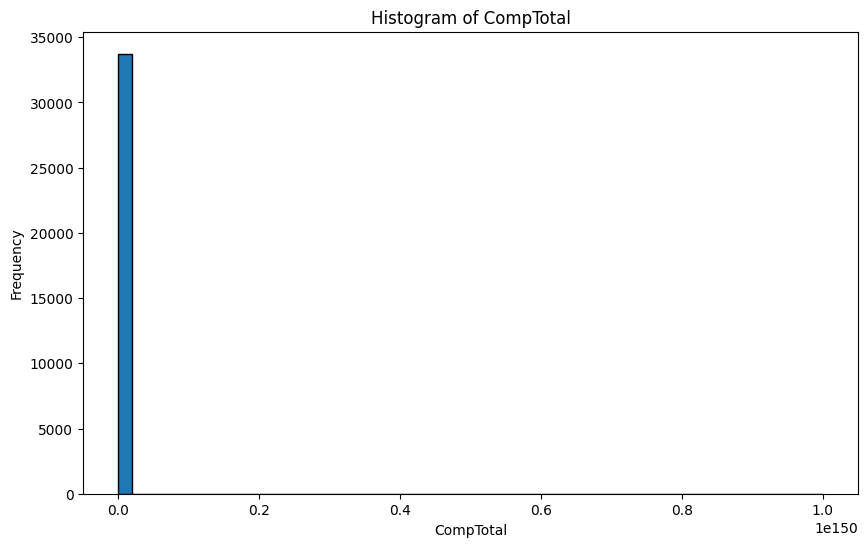

In [7]:
# 1.1 Histogram of CompTotal
# 1.1 Histogram of CompTotal

import re

def parse_numeric_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip().replace(',', '')
    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]

    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
comp_df = pd.read_sql_query(QUERY, conn)

comp_df['CompTotal_num'] = comp_df['CompTotal'].apply(parse_numeric_value)
comp_df = comp_df.dropna(subset=['CompTotal_num'])

plt.figure(figsize=(10, 6))
plt.hist(comp_df['CompTotal_num'], bins=50, edgecolor='black')
plt.title('Histogram of CompTotal')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')
plt.show()















**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


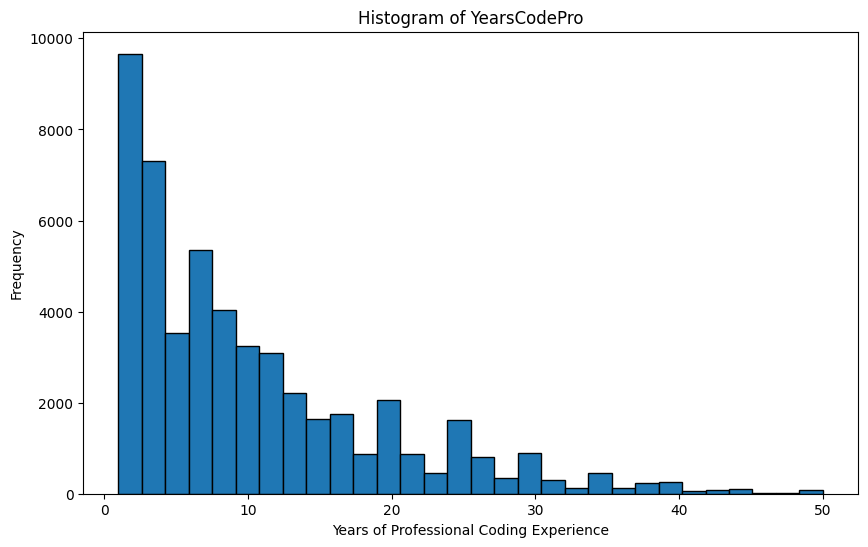

In [8]:
# 1.2 Histogram of YearsCodePro

QUERY = """
SELECT YearsCodePro
FROM main
WHERE YearsCodePro IS NOT NULL
"""
years_df = pd.read_sql_query(QUERY, conn)

years_df['YearsCodePro_num'] = years_df['YearsCodePro'].apply(parse_numeric_value)
years_df = years_df.dropna(subset=['YearsCodePro_num'])

plt.figure(figsize=(10, 6))
plt.hist(years_df['YearsCodePro_num'], bins=30, edgecolor='black')
plt.title('Histogram of YearsCodePro')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Frequency')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


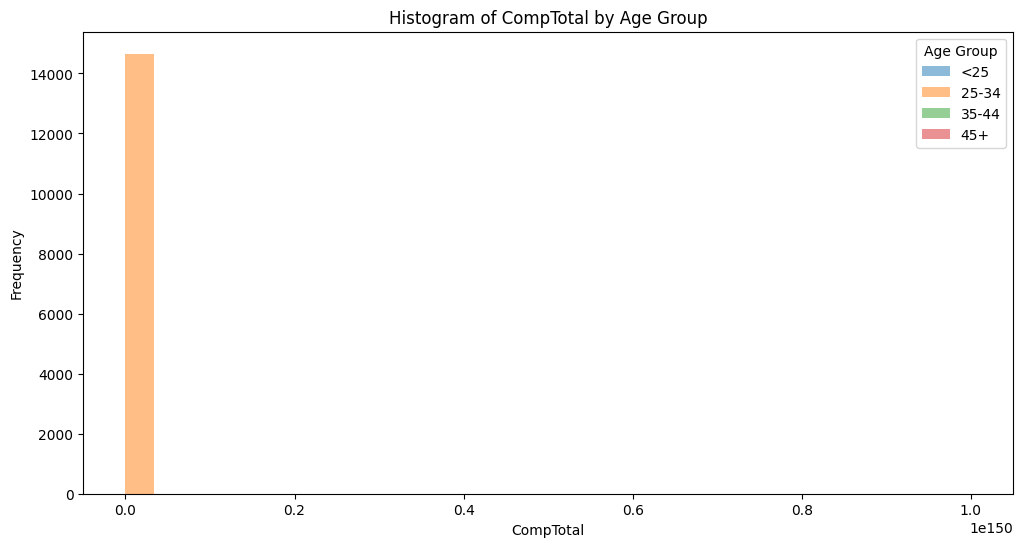

In [16]:
# 2.1 Histogram Comparison of CompTotal by Age Group

import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_numeric_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip().replace(',', '')
    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]

    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

def parse_age_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip()

    age_map = {
        'Under 18 years old': 17,
        '18-24 years old': 21,
        '25-34 years old': 30,
        '35-44 years old': 40,
        '45-54 years old': 50,
        '55-64 years old': 60,
        '65 years or older': 65,
        'Prefer not to say': float('nan')
    }

    if text in age_map:
        return age_map[text]

    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]
    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL AND CompTotal IS NOT NULL
"""
age_comp_df = pd.read_sql_query(QUERY, conn)

age_comp_df['Age_num'] = age_comp_df['Age'].apply(parse_age_value)
age_comp_df['CompTotal_num'] = age_comp_df['CompTotal'].apply(parse_numeric_value)

age_comp_df = age_comp_df.dropna(subset=['Age_num', 'CompTotal_num'])

age_comp_df['AgeGroup'] = pd.cut(
    age_comp_df['Age_num'],
    bins=[0, 25, 35, 45, 100],
    labels=['<25', '25-34', '35-44', '45+'],
    right=False
)

plt.figure(figsize=(12, 6))
for group in ['<25', '25-34', '35-44', '45+']:
    subset = age_comp_df[age_comp_df['AgeGroup'] == group]
    plt.hist(subset['CompTotal_num'], bins=30, alpha=0.5, label=group)

plt.title('Histogram of CompTotal by Age Group')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')
plt.legend(title='Age Group')
plt.show()


















































**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


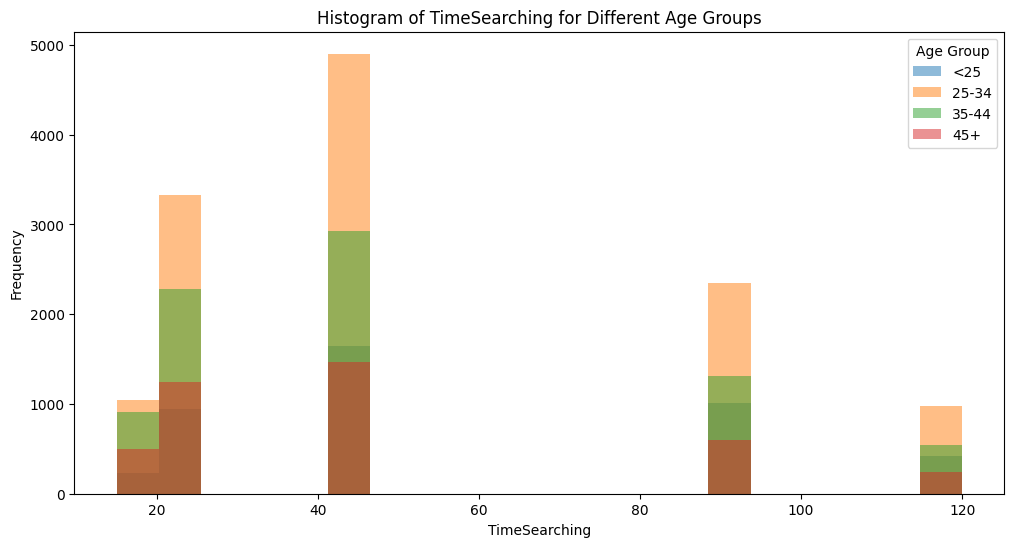

In [17]:
# 2.2 Histogram of TimeSearching for Different Age Groups

# 2.2 Histogram of TimeSearching for Different Age Groups

import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_numeric_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip().replace(',', '')
    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]

    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

def parse_age_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip()

    age_map = {
        'Under 18 years old': 17,
        '18-24 years old': 21,
        '25-34 years old': 30,
        '35-44 years old': 40,
        '45-54 years old': 50,
        '55-64 years old': 60,
        '65 years or older': 65,
        'Prefer not to say': float('nan')
    }

    if text in age_map:
        return age_map[text]

    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]
    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

QUERY = """
SELECT Age, TimeSearching
FROM main
WHERE Age IS NOT NULL AND TimeSearching IS NOT NULL
"""
search_df = pd.read_sql_query(QUERY, conn)

search_df['Age_num'] = search_df['Age'].apply(parse_age_value)
search_df['TimeSearching_num'] = search_df['TimeSearching'].apply(parse_numeric_value)

search_df = search_df.dropna(subset=['Age_num', 'TimeSearching_num'])

search_df['AgeGroup'] = pd.cut(
    search_df['Age_num'],
    bins=[0, 25, 35, 45, 100],
    labels=['<25', '25-34', '35-44', '45+'],
    right=False
)

plt.figure(figsize=(12, 6))

for group in ['<25', '25-34', '35-44', '45+']:
    subset = search_df[search_df['AgeGroup'] == group]
    plt.hist(subset['TimeSearching_num'], bins=20, alpha=0.5, label=group)

plt.title('Histogram of TimeSearching for Different Age Groups')
plt.xlabel('TimeSearching')
plt.ylabel('Frequency')
plt.legend(title='Age Group')
plt.show()
























### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


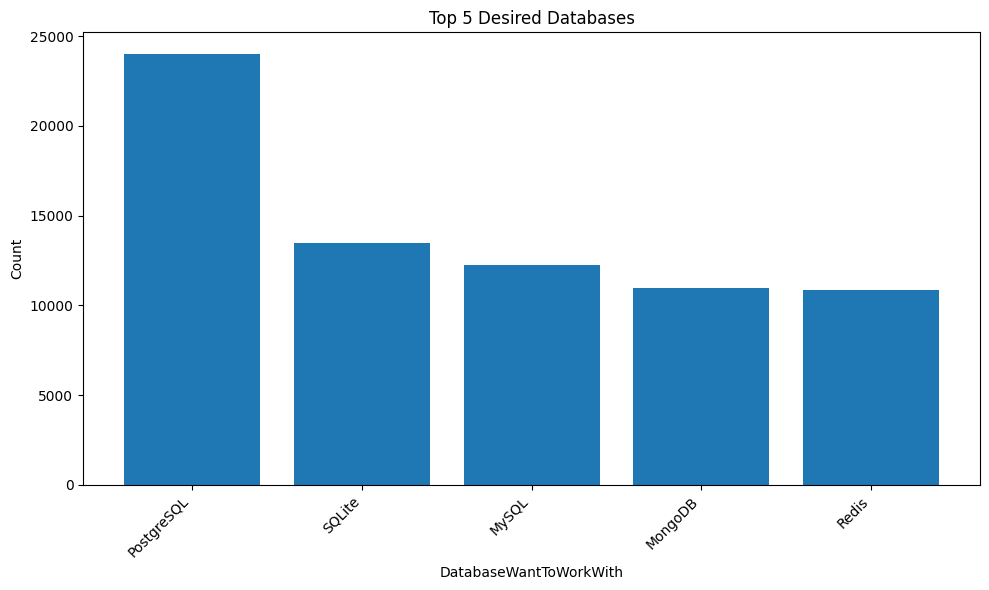

In [11]:
# 3.1 Histogram of Most Desired Databases (top 5)

QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""
db_df = pd.read_sql_query(QUERY, conn)

db_counts = (
    db_df['DatabaseWantToWorkWith']
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .head(5)
)

plt.figure(figsize=(10, 6))
plt.bar(db_counts.index, db_counts.values)
plt.title('Top 5 Desired Databases')
plt.xlabel('DatabaseWantToWorkWith')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


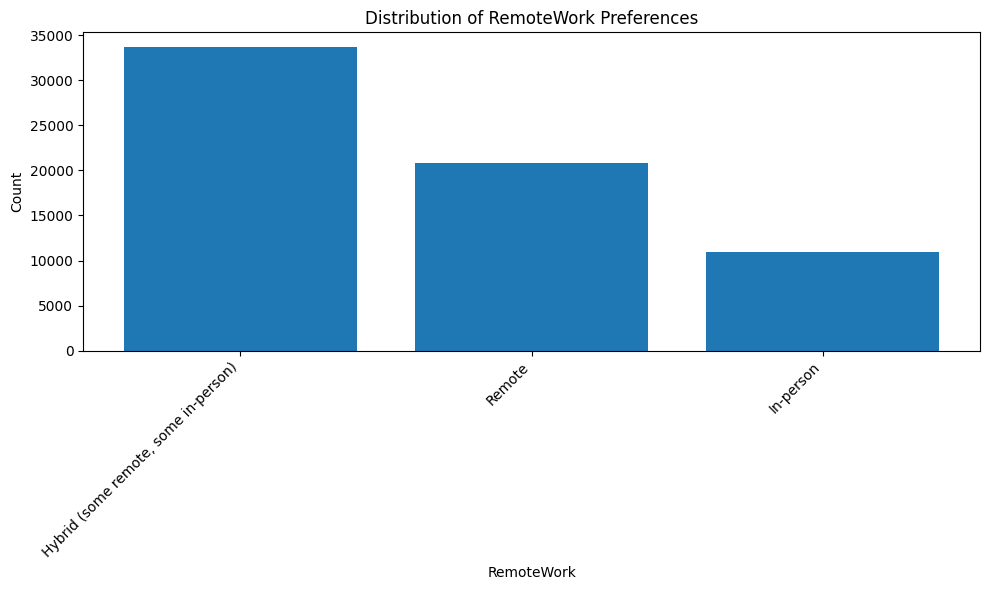

In [12]:
# 3.2 Histogram of Preferred Work Locations (RemoteWork)

QUERY = """
SELECT RemoteWork
FROM main
WHERE RemoteWork IS NOT NULL
"""
remote_df = pd.read_sql_query(QUERY, conn)

remote_counts = remote_df['RemoteWork'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(remote_counts.index, remote_counts.values)
plt.title('Distribution of RemoteWork Preferences')
plt.xlabel('RemoteWork')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


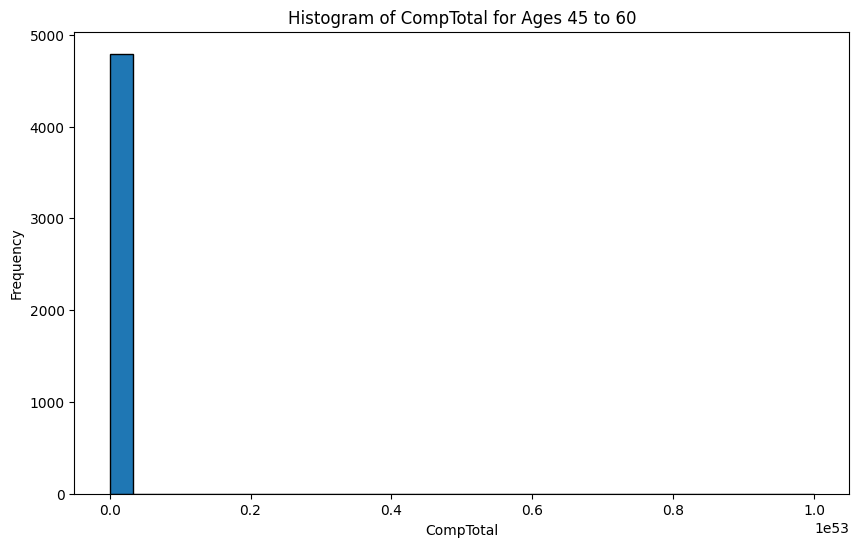

In [18]:
# 4.1 Histogram of CompTotal for Ages 45 to 60

# 4.1 Histogram of CompTotal for Ages 45 to 60

import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_numeric_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip().replace(',', '')
    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]

    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

def parse_age_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip()

    age_map = {
        'Under 18 years old': 17,
        '18-24 years old': 21,
        '25-34 years old': 30,
        '35-44 years old': 40,
        '45-54 years old': 50,
        '55-64 years old': 60,
        '65 years or older': 65,
        'Prefer not to say': float('nan')
    }

    if text in age_map:
        return age_map[text]

    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]
    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL AND CompTotal IS NOT NULL
"""
midcareer_df = pd.read_sql_query(QUERY, conn)

midcareer_df['Age_num'] = midcareer_df['Age'].apply(parse_age_value)
midcareer_df['CompTotal_num'] = midcareer_df['CompTotal'].apply(parse_numeric_value)

midcareer_df = midcareer_df.dropna(subset=['Age_num', 'CompTotal_num'])
midcareer_df = midcareer_df[(midcareer_df['Age_num'] >= 45) & (midcareer_df['Age_num'] <= 60)]

plt.figure(figsize=(10, 6))
plt.hist(midcareer_df['CompTotal_num'], bins=30, edgecolor='black')
plt.title('Histogram of CompTotal for Ages 45 to 60')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')
plt.show()













**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


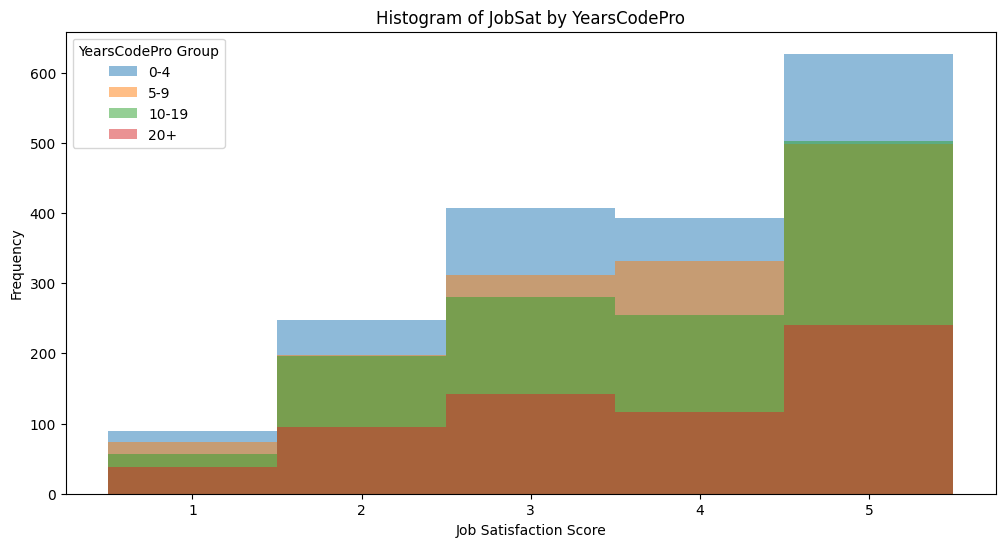

In [19]:
# 4.2 Histogram of JobSat by YearsCodePro
# 4.2 Histogram of Job Satisfaction (JobSat) by YearsCodePro

import pandas as pd
import matplotlib.pyplot as plt
import re

def parse_numeric_value(value):
    if pd.isna(value):
        return float('nan')
    if isinstance(value, (int, float)):
        return float(value)

    text = str(value).strip().replace(',', '')
    numbers = [float(x) for x in re.findall(r'\d+\.?\d*', text)]

    if len(numbers) >= 2:
        return sum(numbers[:2]) / 2
    elif len(numbers) == 1:
        return numbers[0]
    else:
        return float('nan')

def map_jobsat(value):
    if pd.isna(value):
        return float('nan')

    jobsat_map = {
        'Very dissatisfied': 1,
        'Slightly dissatisfied': 2,
        'Neither satisfied nor dissatisfied': 3,
        'Slightly satisfied': 4,
        'Very satisfied': 5
    }

    text = str(value).strip()
    if text in jobsat_map:
        return jobsat_map[text]

    return parse_numeric_value(text)

QUERY = """
SELECT YearsCodePro, JobSat
FROM main
WHERE YearsCodePro IS NOT NULL AND JobSat IS NOT NULL
"""
jobsat_df = pd.read_sql_query(QUERY, conn)

jobsat_df['YearsCodePro_num'] = jobsat_df['YearsCodePro'].apply(parse_numeric_value)
jobsat_df['JobSat_num'] = jobsat_df['JobSat'].apply(map_jobsat)

jobsat_df = jobsat_df.dropna(subset=['YearsCodePro_num', 'JobSat_num'])

jobsat_df['ExperienceGroup'] = pd.cut(
    jobsat_df['YearsCodePro_num'],
    bins=[0, 5, 10, 20, 100],
    labels=['0-4', '5-9', '10-19', '20+'],
    right=False
)

plt.figure(figsize=(12, 6))
for group in ['0-4', '5-9', '10-19', '20+']:
    subset = jobsat_df[jobsat_df['ExperienceGroup'] == group]
    plt.hist(subset['JobSat_num'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], alpha=0.5, label=group)

plt.title('Histogram of JobSat by YearsCodePro')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5])
plt.legend(title='YearsCodePro Group')
plt.show()


























### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [2]:
conn.close()

NameError: name 'conn' is not defined

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
